In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


Text(0.5, 0, 'Classification')

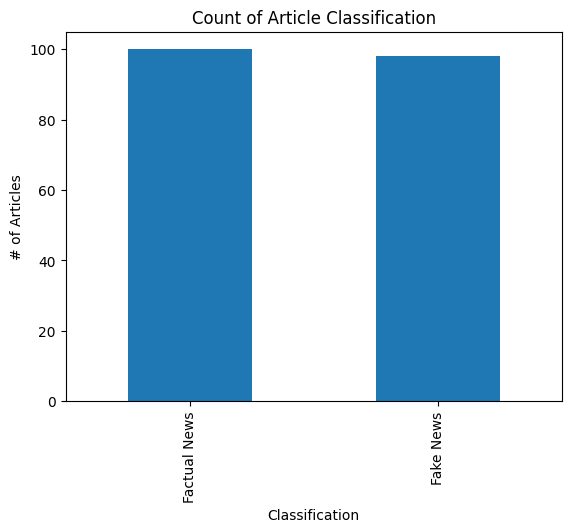

In [3]:
data["fake_or_factual"].value_counts().plot(kind = 'bar')
plt.title('Count of Article Classification')
plt.ylabel('# of Articles')
plt.xlabel('Classification')

### POS Tagging

In [4]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [5]:
# split data by fake and factual news
fake_news = data[data['fake_or_factual'] == "Fake News"]
fact_news = data[data['fake_or_factual'] == "Factual News"]

In [6]:
fake_spacydocs = list(nlp.pipe(fake_news["text"]))
fact_spacydocs = list(nlp.pipe(fact_news["text"]))

In [7]:
fake_tagsdf  = pd.DataFrame([(token.text, token.ent_type_, token.pos_) for doc in fake_spacydocs for token in doc], columns = ["token", "ner_tag", "pos_tag"])

In [8]:
fact_tagsdf   = pd.DataFrame([(token.text, token.ent_type_, token.pos_) for doc in fact_spacydocs for token in doc], columns = ["token", "ner_tag", "pos_tag"])

In [9]:
pos_counts_fake = fake_tagsdf.groupby(['token','pos_tag']).size().reset_index(name="counts").sort_values(ascending=False, by="counts")

In [10]:
pos_counts_fact  = fact_tagsdf.groupby(['token','pos_tag']).size().reset_index(name="counts").sort_values(ascending=False, by="counts")

In [11]:
top_entities_fake = fake_tagsdf[fake_tagsdf["ner_tag"] != ""].groupby(['token','ner_tag']).size().reset_index(name="counts").sort_values(ascending=False, by="counts")

In [12]:
top_entities_fact = fact_tagsdf[fact_tagsdf["ner_tag"] != ""].groupby(['token','ner_tag']).size().reset_index(name="counts").sort_values(ascending=False, by="counts")

In [13]:
import seaborn as sns
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

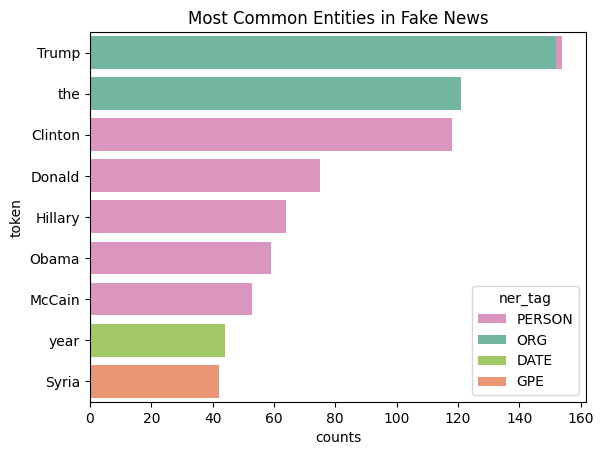

In [14]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[0:10],
    orient = 'h',
    dodge=False
) .set(title='Most Common Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Entities in Factual News')]

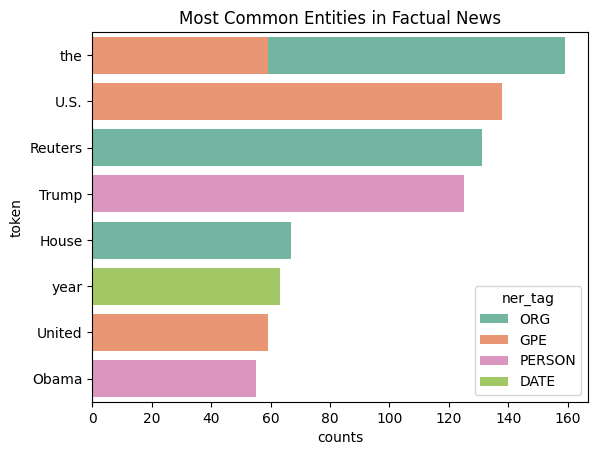

In [15]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most Common Entities in Factual News')

### Text Pre-processing

In [16]:
import regex as re
# a lot of the factual news has a location tag at the beginning of the article, let's use regex to remove this
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s*", "", x['text']), axis=1)

In [17]:
# lowercase 
data['text_clean'] = data['text_clean'].str.lower()

In [18]:
# remove punctuation
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text_clean']), axis=1)

In [19]:
import nltk
from nltk.corpus import stopwords
en_stopwords = stopwords.words('english')

In [20]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [21]:
from nltk.tokenize import word_tokenize
# tokenize 
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis=1)

In [22]:
from nltk.stem import WordNetLemmatizer
# lemmatize
lemmatizer = WordNetLemmatizer()
data["text_clean"] = data["text_clean"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [23]:
from nltk.util import ngrams
tokens_clean = list(token for doc in data["text_clean"] for token in doc)
unigrams= pd.Series(ngrams(tokens_clean,1)).value_counts().reset_index(name="count")
unigrams["token"] = unigrams["index"].apply(lambda r : r[0])
unigrams

,index,count,token
0,"(said,)",560,said
1,"(trump,)",520,trump
2,"(u,)",255,u
3,"(state,)",250,state
4,"(president,)",226,president
...,...,...,...
8567,"(streak,)",1,streak
8568,"(bennewise,)",1,bennewise
8569,"(patsy,)",1,patsy
8570,"(lakeland,)",1,lakeland


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

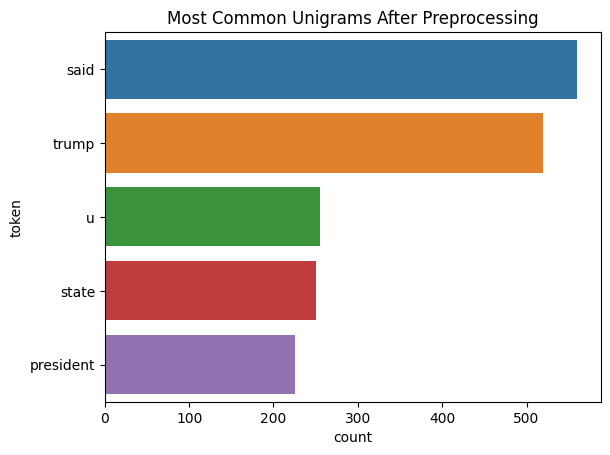

In [24]:
sns.barplot(x = "count", 
            y = "token", 
            data=unigrams.head(),
            orient = 'h',
            hue = "token", legend = False)\
.set(title='Most Common Unigrams After Preprocessing')

### Sentiment Analysis

In [28]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sid_obj = SentimentIntensityAnalyzer()
data['vader_sentiment_score'] = data["text"].apply(lambda text: sid_obj.polarity_scores(text)['compound'])

In [29]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [32]:
data['vader_sentiment_label'] = pd.cut(data["vader_sentiment_score"], [-1, -0.1, 0.1, 1], labels= ['negative', 'neutral', 'positive'])

In [33]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

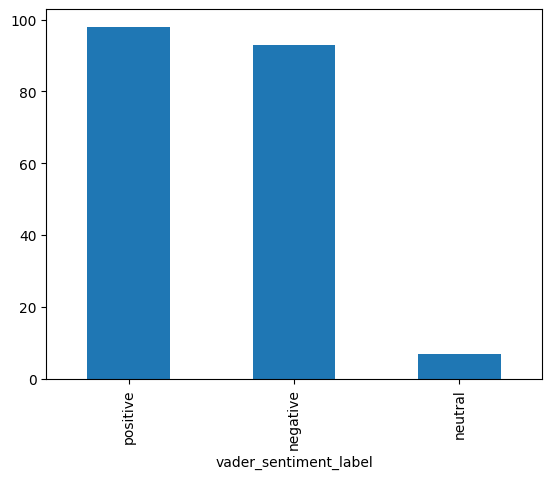

In [35]:
data['vader_sentiment_label'].value_counts().plot.bar()